## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option('display.max_columns', None)

In [3]:
# load data
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

##  Undertanding the data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().values.any()

np.False_

## Data Cleaning

In [10]:
df = df.drop('customerID', axis=1)

In [11]:
df['SeniorCitizen'] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [12]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6094,Male,No,No,No,57,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.55,1252.85,No
1689,Male,No,Yes,Yes,7,No,No phone service,DSL,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,No,Mailed check,58.85,465.7,No
1415,Male,No,No,No,64,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,One year,Yes,Credit card (automatic),100.30,6603.8,No
473,Male,No,Yes,No,24,Yes,No,DSL,Yes,No,No,Yes,No,No,Month-to-month,No,Mailed check,53.60,1315.35,No
2768,Female,No,No,No,12,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.70,260.9,No


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df[df['TotalCharges'].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


All 11 missing records had tenure = 0, which indicating newly acquired customers. So, TotalCharges will be set to 0

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [17]:
df.isna().values.any()

np.False_

In [18]:
df.shape

(7043, 20)

In [19]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [20]:
df.describe(include="object")

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## Identify Categorical and Numerical Columns

In [21]:
categorical_cols = df.select_dtypes(include='object').columns
numwrical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f'Numerical features: {numwrical_cols.to_list()}')
print(f'Categorical features: {categorical_cols.to_list()}')

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [22]:
for col in categorical_cols: 
    print(df[col].value_counts(), '\n')

gender
Male      3555
Female    3488
Name: count, dtype: int64 

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet

## Exploratory Data Analysis

In [23]:
churn_count = df['Churn'].value_counts()

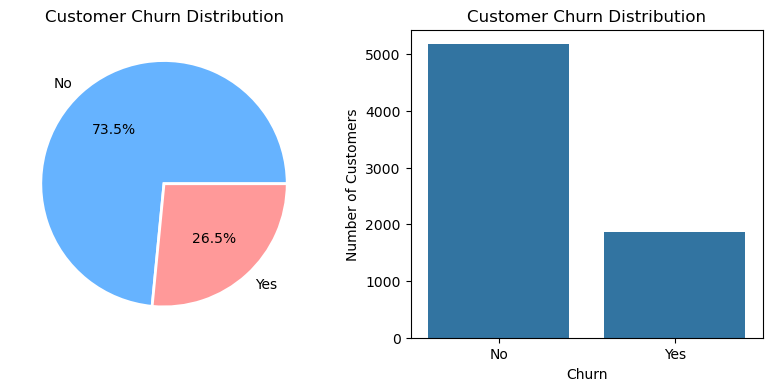

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 

ax1.pie(
    churn_count.values, 
    labels=churn_count.index, 
    colors=['#66b3ff','#ff9999'], 
    autopct='%1.1f%%',     
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  
)
ax1.set_title('Customer Churn Distribution')

sns.barplot(churn_count, ax=ax2)
ax2.set_title("Customer Churn Distribution")
ax2.set_xlabel("Churn")
ax2.set_ylabel("Number of Customers")

plt.show()

In [25]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='gender', 
    barmode='group',
    title='Churn Distribution with respect to Gender',
    width=1000,
    height=400
)


fig.show()

In [26]:

fig = px.histogram(
    df, 
    x='Churn', 
    color='Contract', 
    barmode='group',
    title='Churn Distribution with respect to Contract',
    width=1000,
    height=400
)


fig.show()

In [27]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='InternetService', 
    barmode='group',
    title='Churn Distribution with respect to Internet Service',
    width=1000,
    height=400
)

fig.show()

In [28]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='PaymentMethod', 
    barmode='group',
    title='Churn Distribution with respect to Payment Method',
    width=1000,
    height=400
)

fig.show()

In [29]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='TechSupport', 
    barmode='group',
    title='Churn Distribution with respect to Tech Support',
    width=1000,
    height=400
)

fig.show()

In [30]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='OnlineSecurity', 
    barmode='group',
    title='Churn Distribution with respect to Online Security',
    width=1000,
    height=400
)

fig.show()

In [31]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='PaperlessBilling', 
    barmode='group',
    title='Churn Distribution with respect to Online PaperlessBilling',
    width=1000,
    height=400
)

fig.show()

In [32]:
fig = px.histogram(
    df, 
    x='Churn', 
    color='SeniorCitizen', 
    barmode='group',
    title='Churn Distribution with respect to Senior Citizen',
    width=1000,
    height=400
)

fig.show()

In [33]:
fig = px.box(
    df, 
    x='Churn',
    y='tenure',
    color='Churn',
    title='Tenure Distribution by Churn',
    width=1000,
    height=500
)

fig.show()

In [34]:
fig = px.box(
    df, 
    x='Churn',
    y='tenure',
    color='Churn',
    title='Tenure Distribution by Churn',
    width=1000,
    height=500
)

fig.show()

In [35]:
fig = px.box(
    df, 
    x='Churn',
    y='MonthlyCharges',
    color='Churn',
    title='Monthly Charges Distribution by Churn',
    width=1000,
    height=500
)

fig.show()

In [36]:
fig = px.box(
    df, 
    x='Churn',
    y='TotalCharges',
    color='Churn',
    title='Total Charges Distribution by Churn',
    width=1000,
    height=500
)

fig.show()

In [37]:
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

In [38]:
corr['Churn'].sort_values(ascending=False)

Churn               1.000000
SeniorCitizen       0.150889
Partner             0.150448
MultipleLines       0.036310
MonthlyCharges      0.020966
PhoneService        0.011942
gender             -0.008612
TotalCharges       -0.027614
InternetService    -0.047291
OnlineBackup       -0.074205
tenure             -0.144351
Dependents         -0.164221
PaperlessBilling   -0.191825
StreamingTV        -0.205742
StreamingMovies    -0.207256
PaymentMethod      -0.262818
DeviceProtection   -0.281465
TechSupport        -0.329852
OnlineSecurity     -0.332819
Contract           -0.396713
Name: Churn, dtype: float64

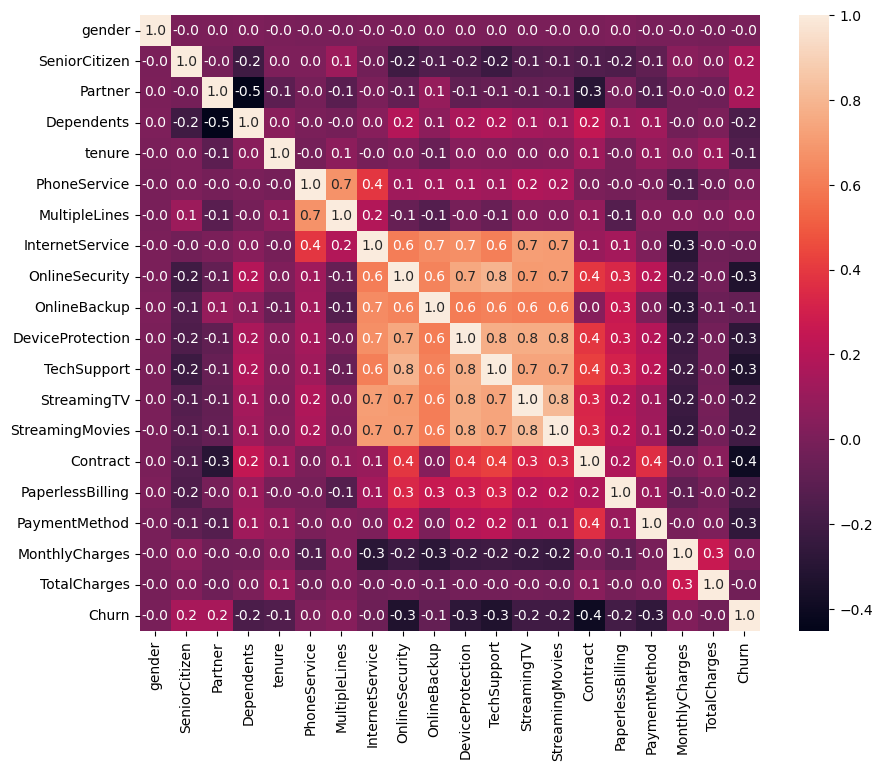

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".1f")
plt.show()

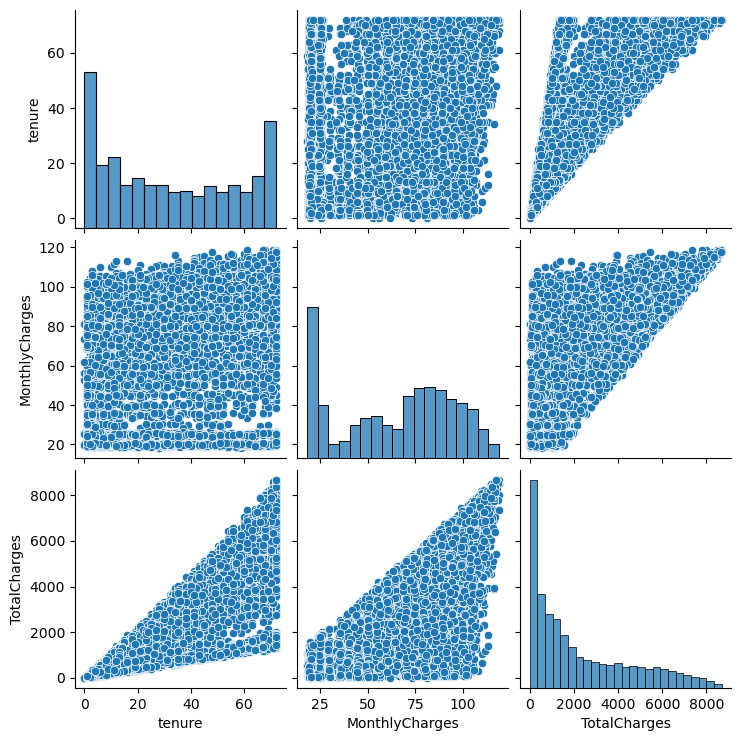

In [40]:
sns.pairplot(df)

## Generate full EDR report using pandas profilling

In [44]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Dataset Report")

In [45]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 37.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
# Save the report as a HTML file 
profile.to_file('EDA.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]